In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

Mounted at /content/drive


In [2]:
# -------------------------------------------------------
# Paths
# -------------------------------------------------------
PROJECT_DIR = Path("/content/drive/MyDrive/HAR_1D_CNN_Project")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------
# Load engineered features and labels
# -------------------------------------------------------
X_train_features = pd.read_csv(PROCESSED_DIR / "X_train_features.csv")
X_test_features = pd.read_csv(PROCESSED_DIR / "X_test_features.csv")

y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

subjects_train = np.load(PROCESSED_DIR / "subjects_train.npy")
subjects_test = np.load(PROCESSED_DIR / "subjects_test.npy")

ACTIVITY_NAMES = {
    1: "Walking",
    2: "Walking Upstairs",
    3: "Walking Downstairs",
    4: "Sitting",
    5: "Standing",
    6: "Laying"
}

print("Engineered train features:", X_train_features.shape)
print("Engineered test features: ", X_test_features.shape)
print("Train labels:", y_train.shape)
print("Test labels: ", y_test.shape)

Engineered train features: (7352, 561)
Engineered test features:  (2947, 561)
Train labels: (7352,)
Test labels:  (2947,)


In [3]:
# -------------------------------------------------------
# Subject-aware validation split
# Same split used for the CNN
# -------------------------------------------------------
VAL_SUBJECTS = np.array([27, 28, 29, 30])

train_mask = ~np.isin(subjects_train, VAL_SUBJECTS)
val_mask = np.isin(subjects_train, VAL_SUBJECTS)

X_rf_train = X_train_features.loc[train_mask].copy()
X_rf_val = X_train_features.loc[val_mask].copy()

y_rf_train = y_train[train_mask]
y_rf_val = y_train[val_mask]

print("RF train shape:", X_rf_train.shape)
print("RF val shape:  ", X_rf_val.shape)

print("\nTraining subjects:", sorted(np.unique(subjects_train[train_mask])))
print("Validation subjects:", sorted(np.unique(subjects_train[val_mask])))

assert set(np.unique(subjects_train[train_mask])).isdisjoint(
    set(np.unique(subjects_train[val_mask]))
)

print("\nNo subject leakage: PASSED")

RF train shape: (5867, 561)
RF val shape:   (1485, 561)

Training subjects: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26)]
Validation subjects: [np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

No subject leakage: PASSED


In [4]:
# -------------------------------------------------------
# Small, controlled baseline selection using validation data
# -------------------------------------------------------
candidates = [
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1},
]

validation_results = []

for config in candidates:
    print(f"\nTraining: {config}")

    rf = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_rf_train, y_rf_train)
    val_pred = rf.predict(X_rf_val)
    val_acc = accuracy_score(y_rf_val, val_pred)

    validation_results.append({
        **config,
        "validation_accuracy": val_acc
    })

    print(f"Validation Accuracy: {val_acc:.4f}")

validation_df = pd.DataFrame(validation_results).sort_values(
    "validation_accuracy",
    ascending=False
).reset_index(drop=True)

display(validation_df)


Training: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1}
Validation Accuracy: 0.9535

Training: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1}
Validation Accuracy: 0.9529


,n_estimators,max_depth,min_samples_leaf,validation_accuracy
0,200,None,1,0.953535
1,300,None,1,0.952862


In [5]:
# -------------------------------------------------------
# Select best validation configuration
# -------------------------------------------------------
best_config = validation_df.iloc[0].to_dict()

print("Selected configuration:")
print(best_config)

# -------------------------------------------------------
# Retrain using ALL official training data
# The official test partition remains untouched until evaluation.
# -------------------------------------------------------
rf_final = RandomForestClassifier(
    n_estimators=int(best_config["n_estimators"]),
    max_depth=best_config["max_depth"],
    min_samples_leaf=int(best_config["min_samples_leaf"]),
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_features, y_train)

print("\nFinal Random Forest trained on all official training data.")

Selected configuration:
{'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'validation_accuracy': 0.9535353535353536}

Final Random Forest trained on all official training data.


In [6]:
# -------------------------------------------------------
# Final test evaluation
# -------------------------------------------------------
test_pred = rf_final.predict(X_test_features)
test_acc = accuracy_score(y_test, test_pred)

print(f"Official Test Accuracy: {test_acc:.4f}\n")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[ACTIVITY_NAMES[i] for i in range(1, 7)],
        digits=4
    )
)

Official Test Accuracy: 0.9257

                    precision    recall  f1-score   support

           Walking     0.8998    0.9597    0.9288       496
  Walking Upstairs     0.8884    0.9130    0.9005       471
Walking Downstairs     0.9572    0.8524    0.9018       420
           Sitting     0.9158    0.8859    0.9006       491
          Standing     0.8978    0.9248    0.9111       532
            Laying     1.0000    1.0000    1.0000       537

          accuracy                         0.9257      2947
         macro avg     0.9265    0.9226    0.9238      2947
      weighted avg     0.9267    0.9257    0.9255      2947



In [7]:
# -------------------------------------------------------
# Save predictions and model-selection summary
# -------------------------------------------------------
np.save(RESULTS_DIR / "rf_test_predictions.npy", test_pred)

validation_df.to_csv(
    TABLES_DIR / "random_forest_validation_results.csv",
    index=False
)

final_metrics = pd.DataFrame([{
    "model": "Random Forest (561 handcrafted features)",
    "test_accuracy": test_acc,
    "n_estimators": int(best_config["n_estimators"]),
    "max_depth": best_config["max_depth"],
    "min_samples_leaf": int(best_config["min_samples_leaf"])
}])

final_metrics.to_csv(
    TABLES_DIR / "random_forest_test_metrics.csv",
    index=False
)

display(final_metrics)

print("Saved predictions and metrics to:", RESULTS_DIR)

,model,test_accuracy,n_estimators,max_depth,min_samples_leaf
0,Random Forest (561 handcrafted features),0.925687,200,None,1


Saved predictions and metrics to: /content/drive/MyDrive/HAR_1D_CNN_Project/results


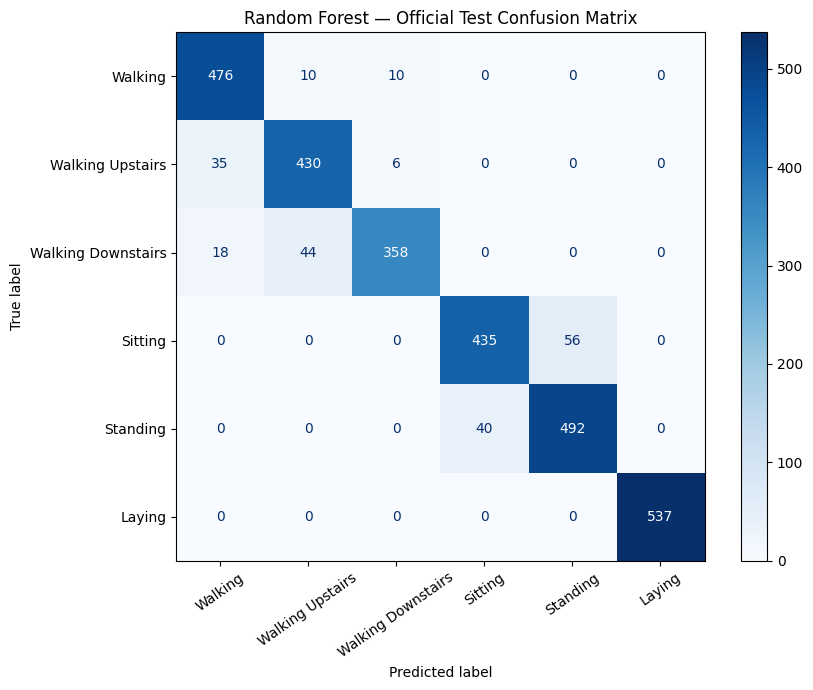

Saved figure: /content/drive/MyDrive/HAR_1D_CNN_Project/results/figures/random_forest_confusion_matrix.png


In [8]:
# -------------------------------------------------------
# Confusion matrix
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=[ACTIVITY_NAMES[i] for i in range(1, 7)],
    cmap="Blues",
    xticks_rotation=35,
    values_format="d",
    ax=ax
)

ax.set_title("Random Forest — Official Test Confusion Matrix")
plt.tight_layout()

figure_path = FIGURES_DIR / "random_forest_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

## Random Forest baseline

The UCI HAR dataset includes 561 handcrafted time-domain and frequency-domain features. A Random Forest classifier was trained on these features as a classical machine-learning baseline.

Two small model configurations were compared using a subject-aware validation split. The selected configuration was retrained on the complete official training partition and evaluated once on the untouched official test partition.

This baseline is intentionally strong because the engineered features encode domain knowledge. The 1D CNN will instead receive only raw 9-channel sensor sequences and learn temporal features automatically.